# 注意力其实很稀疏：块稀疏入门

FlashAttention 把 full 注意力做到了又快又省显存，但它的计算量仍是 $O(S^2)$——每个 query 都要
和每个 key 算一遍。可你若真去看一眼注意力矩阵会发现：**大部分权重都集中在少数几段上下文**，
其余几乎是零。那为什么还要全算？

这一章我们走进**稀疏注意力**：把 key 切成块，每个 query 块只挑**最相关的 top-k 个 key 块**来算。
这是 DeepSeek NSA 等方法的核心地基。我们先用纯 PyTorch 把"选块 + 稀疏算"的机制讲透，
下一章再去读真正的稀疏 Triton kernel。


In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "07-block-sparse-attention"))

from common import make_qkv, naive_attention, bench_ms
from block_sparse import select_topk_blocks, block_sparse_reference, block_sparse_attention, _pool_blocks

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

# 中文正常显示 + 暗色代码高亮（适配深色编辑器），见 common/nbtools.py
from common.nbtools import setup_cjk, show_code
setup_cjk()


跑在 NVIDIA GeForce RTX 4090


'Noto Sans SC'

## 先亲眼看看：注意力到底有多稀疏

我们算一个真实的因果注意力矩阵，把它画出来，再统计每个 query "真正在意"的 key 有多少。


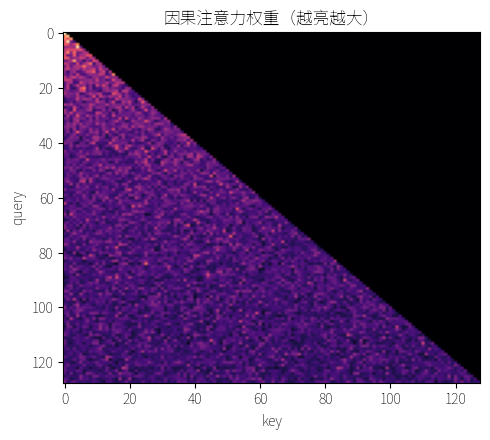

平均每个 query 要累计 90% 注意力，只需 40 个 key（共最多 128 个可见）——其余几乎是零。


In [2]:
q, k, v = make_qkv(1, 1, 128, 64, dtype=torch.float16, seed=0)
scores = (q.float() @ k.float().transpose(-1, -2)) / math.sqrt(64)
S = q.shape[2]
scores = scores.masked_fill(~torch.ones(S, S, device=q.device).tril().bool(), float("-inf"))
attn = torch.softmax(scores, dim=-1)[0, 0]      # (S,S)

plt.figure(figsize=(5, 4.5))
plt.imshow(attn.cpu().float().pow(0.3), cmap="magma", aspect="auto")  # ^0.3 提亮，便于看清
plt.title("因果注意力权重（越亮越大）"); plt.xlabel("key"); plt.ylabel("query")
plt.tight_layout(); plt.show()

# 每个 query：要累计到 90% 权重，平均需要多少个 key？
sorted_w = attn.sort(dim=-1, descending=True).values
cum = sorted_w.cumsum(-1)
need = (cum < 0.9).sum(-1).float() + 1          # 达到 90% 权重所需的 key 数
valid = torch.arange(1, S + 1, device=q.device).float()  # 每个 query 的可见 key 数(causal)
print(f"平均每个 query 要累计 90% 注意力，只需 {need.mean():.0f} 个 key（共最多 {S} 个可见）——其余几乎是零。")


## 三步：分块 → 选块 → 稀疏算

既然注意力这么稀疏，那就别全算。做三件事：

1. **分块 + pooled 代表**：把 query/key 按块取均值，每块得到一个"代表向量"；
2. **块级重要性 + top-k 选块**：用代表向量两两打分，每个 query 块选最相关的 top-k 个 key 块；
3. **稀疏计算**：只对选中的块算注意力。

第②步是灵魂。我们把"块级重要性矩阵"和"最终选中的块"并排画出来看：


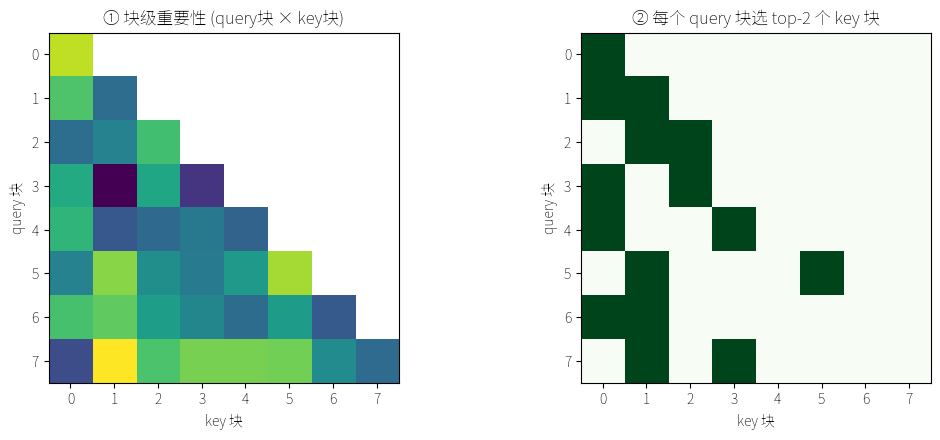

右图每行只有 2 个绿格——8 个 key 块里只算这 2 个，其余跳过。


In [3]:
q, k, v = make_qkv(1, 1, 256, 64, dtype=torch.float16, seed=1)
block_size, top_k = 32, 2
nb = 256 // block_size

q_blk, k_blk = _pool_blocks(q, block_size), _pool_blocks(k, block_size)
imp = (q_blk.float() @ k_blk.float().transpose(-1, -2) / math.sqrt(64))[0, 0]   # (nb,nb)
causal = torch.ones(nb, nb, device=q.device).tril().bool()
imp_vis = imp.masked_fill(~causal, float("nan"))

idx = select_topk_blocks(q, k, block_size, top_k, causal=True)[0, 0]            # (nb, top_k)
sel = torch.zeros(nb, nb, dtype=torch.bool, device=q.device)
sel.scatter_(1, idx, True); sel &= causal

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.imshow(imp_vis.cpu().float(), cmap="viridis"); ax1.set(title="① 块级重要性 (query块 × key块)", xlabel="key 块", ylabel="query 块")
ax2.imshow(sel.cpu().float(), cmap="Greens"); ax2.set(title=f"② 每个 query 块选 top-{top_k} 个 key 块", xlabel="key 块", ylabel="query 块")
plt.tight_layout(); plt.show()
print(f"右图每行只有 {top_k} 个绿格——{nb} 个 key 块里只算这 {top_k} 个，其余跳过。")


## 看看稀疏算子的代码

`block_sparse.py` 把这三步实现成两条路径：`block_sparse_reference`（mask + full，作 ground truth）
和 `block_sparse_attention`（gather 选中块、只算选中块）。直接读一下后者——稀疏计算就发生在这里：


In [4]:
from IPython.display import Code
show_code(str(ROOT / "07-block-sparse-attention" / "block_sparse.py"))


## 验证：两条路径一致，全选时退化为 full

- gather 省算实现，必须和 mask 参考实现数值一致；
- 当 top-k 取满（选中所有块）时，块稀疏必须退化成普通 full 注意力。


In [5]:
q, k, v = make_qkv(2, 4, 512, 64, dtype=torch.float16, seed=2)
nb = 512 // 64

# gather ≡ reference
for tk in [1, 2, 4]:
    ref = block_sparse_reference(q, k, v, 64, tk, causal=True)
    gat = block_sparse_attention(q, k, v, 64, tk, causal=True)
    print(f"top_k={tk}: gather vs mask参考 最大差异 {(ref-gat).abs().max().item():.1e}  ✓")

# 全选 ≡ full
full = naive_attention(q, k, v, causal=True)
allsel = block_sparse_reference(q, k, v, 64, top_k=nb, causal=True)
print(f"\ntop_k={nb}(全选) vs full 注意力 最大差异 {(full-allsel).abs().max().item():.1e}  ✓ 退化为 full")


top_k=1: gather vs mask参考 最大差异 0.0e+00  ✓
top_k=2: gather vs mask参考 最大差异 2.4e-04  ✓
top_k=4: gather vs mask参考 最大差异 2.4e-04  ✓

top_k=8(全选) vs full 注意力 最大差异 0.0e+00  ✓ 退化为 full


## 省了多少？以及为什么还需要稀疏 kernel

块稀疏只算选中块，所以 top-k 越小越快。但我们的 gather 是**纯 PyTorch**（gather/scatter 有开销），
和融合的 SDPA 比并不占便宜。看数据：


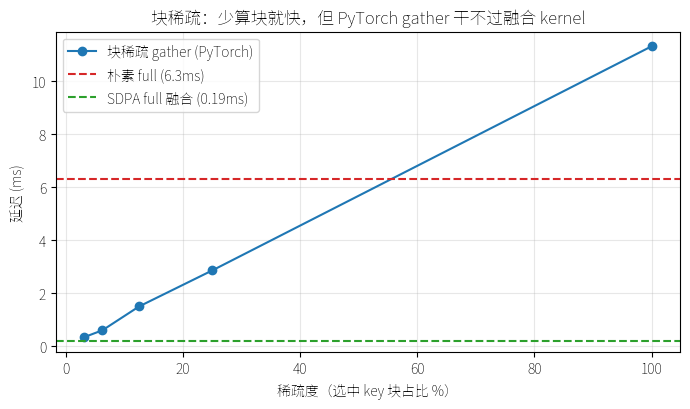

选 2/32 块(6%): 0.61ms，比朴素 full 快 10×，但仍慢于 SDPA 的 0.19ms。


In [6]:
S, block_size, nb = 2048, 64, 32
q, k, v = make_qkv(4, 8, S, 64, dtype=torch.float16, seed=0)
ms_naive = bench_ms(lambda: naive_attention(q, k, v, causal=True))
ms_sdpa = bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True))

tks = [1, 2, 4, 8, nb]
lat = [bench_ms(lambda tk=tk: block_sparse_attention(q, k, v, block_size, tk, causal=True)) for tk in tks]

plt.figure(figsize=(7, 4.2))
plt.plot([t/nb*100 for t in tks], lat, "o-", label="块稀疏 gather (PyTorch)")
plt.axhline(ms_naive, ls="--", c="C3", label=f"朴素 full ({ms_naive:.1f}ms)")
plt.axhline(ms_sdpa, ls="--", c="C2", label=f"SDPA full 融合 ({ms_sdpa:.2f}ms)")
plt.xlabel("稀疏度（选中 key 块占比 %）"); plt.ylabel("延迟 (ms)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("块稀疏：少算块就快，但 PyTorch gather 干不过融合 kernel")
plt.tight_layout(); plt.show()
print(f"选 2/{nb} 块(6%): {lat[1]:.2f}ms，比朴素 full 快 {ms_naive/lat[1]:.0f}×，但仍慢于 SDPA 的 {ms_sdpa:.2f}ms。")


## 深度优化版：复用 08 NSA 的真实 triton kernel

上面说"要既稀疏又快，必须把选块 + 稀疏算焊进一个 Triton kernel"。这样的 kernel 长什么样？其实 07 的
"动态 top-k 块稀疏"**正是 08 NSA 的 selected 分支** —— 开源生态里没有独立、干净、4090 可跑的"动态块
稀疏 triton kernel"（NSA 那种与压缩/滑窗耦合、MoBA 用 flash_attn、triton 旧 blocksparse 已移除），
所以本章深度优化版直接**复用 08 已提取并验证的** `native_sparse_attend`。

**语义升级：对角块必看 + top-k 历史块。** 真实 kernel 比简要版的"纯 top-k"多一条规矩：当前块（对角块）
**总是**算（NSA 用 Part1 处理对角块、selected 只选互补的历史块）。这是动态块稀疏的通用工程选择。

In [7]:
from block_sparse_triton import block_sparse_attention_triton, block_sparse_nsa_reference

qd, kd, vd = make_qkv(2, 4, 512, 64, dtype=torch.float16, seed=3)
bs2, nb2 = 64, 512 // 64

# 锚点：选满所有历史块 → 退化为 full causal
o_full = block_sparse_attention_triton(qd, kd, vd, bs2, top_k=nb2)
full = naive_attention(qd, kd, vd, causal=True)
print(f"全历史选块 vs full causal   max diff = {(o_full - full).abs().max().item():.5f}")

# 各 top-k：复用的 NSA kernel vs 匹配语义的 PyTorch 参考（对角块 + top-k 历史块）
for tk in [1, 2, 4]:
    o = block_sparse_attention_triton(qd, kd, vd, bs2, tk)
    r = block_sparse_nsa_reference(qd, kd, vd, bs2, tk)
    print(f"top_k={tk}: 复用 NSA kernel vs 参考   max diff = {(o - r).abs().max().item():.4f}")
print("→ 复用 08 NSA selected kernel：语义=对角块必看+top-k历史，全历史时退化为 full causal。")

全历史选块 vs full causal   max diff = 0.00195
top_k=1: 复用 NSA kernel vs 参考   max diff = 0.0020
top_k=2: 复用 NSA kernel vs 参考   max diff = 0.0020
top_k=4: 复用 NSA kernel vs 参考   max diff = 0.0020
→ 复用 08 NSA selected kernel：语义=对角块必看+top-k历史，全历史时退化为 full causal。


## 对照：MoBA —— 另一条动态块稀疏路线

Kimi 的 **MoBA**（Mixture of Block Attention）是与 NSA 同期的动态块稀疏。纯 PyTorch 参考
`moba_naive.py` 可直接跑：chunk 级动态 top-k 选块 + **当前块强制选中**（和本章"对角块必看"一个道理）。

In [8]:
from moba_naive import moba_attn_varlen_naive

S2 = 256
qm = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
km = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
vm = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
cu = torch.tensor([0, S2], device="cuda", dtype=torch.int32)

o_moba = moba_attn_varlen_naive(qm, km, vm, cu, S2, moba_chunk_size=64, moba_topk=2)
print("MoBA naive 输出:", tuple(o_moba.shape))

# 选满所有 chunk → full causal
o_all = moba_attn_varlen_naive(qm, km, vm, cu, S2, moba_chunk_size=64, moba_topk=S2 // 64)
fm = naive_attention(qm.transpose(0, 1)[None], km.transpose(0, 1)[None],
                     vm.transpose(0, 1)[None], causal=True)[0].transpose(0, 1)
print(f"MoBA 全选 vs full causal     max diff = {(o_all - fm).abs().max().item():.5f}")
print("→ MoBA：chunk 级动态选块 + 当前块必选；高效版用 flash_attn varlen 编排（见 moba_efficient.py）。")

MoBA naive 输出: (256, 2, 64)
MoBA 全选 vs full causal     max diff = 0.00000
→ MoBA：chunk 级动态选块 + 当前块必选；高效版用 flash_attn varlen 编排（见 moba_efficient.py）。


In [9]:
from IPython.display import Code
# MoBA 的纯 PyTorch 参考（可跑）；高效版 moba_efficient.py 依赖 flash_attn，仅供阅读
show_code(str(ROOT / "07-block-sparse-attention" / "moba_naive.py"))

### 两条落地路线对照

| | 08 NSA（07 深度优化版复用） | MoBA |
|---|---|---|
| 高效实现 | **自写**稀疏 triton kernel（选块 gather 融进 flash） | **借** flash_attn varlen + 数据重排 |
| 当前块 | 对角块必看（kernel Part1） | 当前块必选（gate=inf） |
| 依赖 | triton / einx（本仓库已跑通 fwd+bwd） | flash-attn（本环境未装；naive 版可跑） |

都"动态选块"，但工程路线不同：自写 kernel（NSA）极致但难写；借 flash_attn（MoBA）省力但受限于 flash 的接口。

## 收尾

- 注意力天然**稀疏**：每个 query 的权重集中在少数块上；
- 块稀疏三步——分块取代表 → 块级 top-k 选块 → 只算选中块；
- **简要版**（`block_sparse.py`）用纯 PyTorch 讲清机制（纯 top-k）；**深度优化版**
  （`block_sparse_triton.py`）复用 08 NSA 的真实 triton kernel（语义=对角块必看+top-k历史），
  证明"既稀疏又快"要靠融合 kernel；
- **MoBA 对照**（`moba_naive.py` / `moba_efficient.py`）展示了动态块稀疏的另一条落地路线。

**下一站** → `08-native-sparse-attention`：把"压缩 + 选择 + 滑窗"三分支门控合并，逐段精读那 1987 行
真实稀疏 Triton kernel。